In [1]:
# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================
# Libraries are tools that help us perform data analysis
# and machine learning tasks.

import pandas as pd          # Used for working with datasets (tables)
import numpy as np           # Used for numerical calculations
import matplotlib.pyplot as plt   # Used for creating graphs

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split   # Splits dataset into training and testing
from sklearn.preprocessing import LabelEncoder         # Converts text data into numbers
from sklearn.linear_model import LinearRegression      # Machine learning model used for prediction
from sklearn.metrics import mean_squared_error, r2_score   # Used to evaluate model performance

In [2]:
# =====================================================
# STEP 2: LOAD DATASET
# =====================================================
# Read the student performance dataset from CSV file.

data = pd.read_csv("student_performance_data.csv")

# Display first 5 rows to understand the dataset structure
print("First 5 rows of dataset:")
print(data.head().T)

First 5 rows of dataset:
                               0          1         2        3          4
StudentID                      1          2         3        4          5
Gender                      Male     Female      Male     Male       Male
Age                           24         22        22       24         18
StudyHoursPerWeek             37         37        10       10         19
AttendanceRate             90.75       74.9     53.36    70.26      74.87
GPA                         3.47       2.32      2.38     3.46       2.31
Major                       Arts  Education  Business  Science  Education
PartTimeJob                  Yes         No        No      Yes        Yes
ExtraCurricularActivities     No         No        No       No         No


In [3]:
# =====================================================
# STEP 3: DATA UNDERSTANDING
# =====================================================
# Check basic information about the dataset.

# Check number of rows and columns
print("Dataset shape:")
print(data.shape)

# Check column names and data types
print("\nDataset information:")
print(data.info())

# Statistical summary of numeric columns
print("\nStatistical summary:")
print(data.describe())

# Check missing values in each column
print("\nMissing values in dataset:")
print(data.isnull().sum())

Dataset shape:
(500, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  500 non-null    int64  
 1   Gender                     500 non-null    object 
 2   Age                        500 non-null    int64  
 3   StudyHoursPerWeek          500 non-null    int64  
 4   AttendanceRate             500 non-null    float64
 5   GPA                        500 non-null    float64
 6   Major                      500 non-null    object 
 7   PartTimeJob                500 non-null    object 
 8   ExtraCurricularActivities  500 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 35.3+ KB
None

Statistical summary:
        StudentID         Age  StudyHoursPerWeek  AttendanceRate        GPA
count  500.000000  500.000000         500.000000      500.000000  50

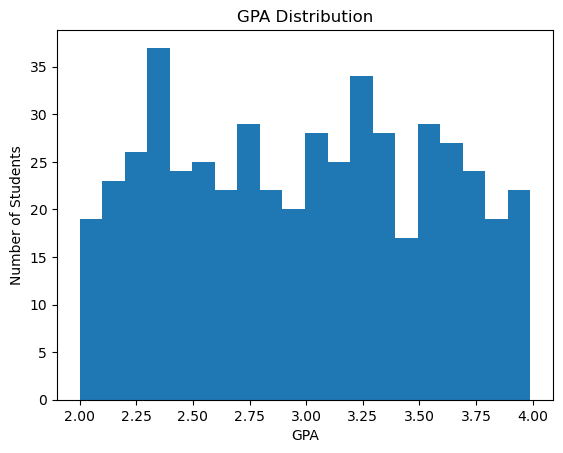

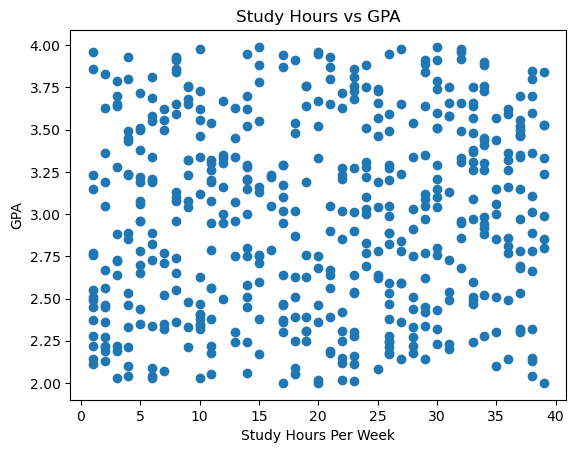

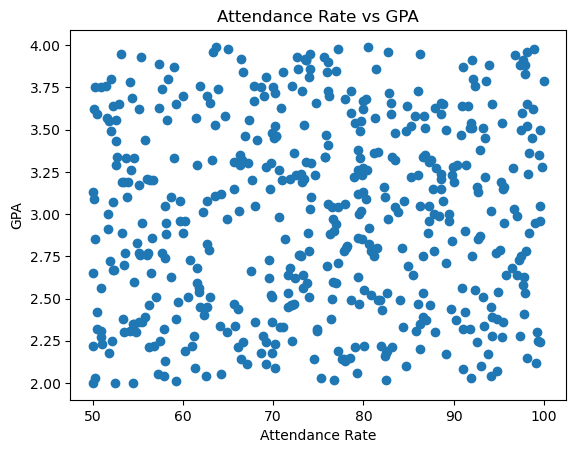

In [4]:
# =====================================================
# STEP 4: DATA VISUALIZATION
# =====================================================
# Visualize relationships between variables.

# 1. Distribution of GPA values
plt.hist(data['GPA'], bins=20)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Number of Students")

plt.show()

# 2. Study Hours vs GPA

plt.scatter(data['StudyHoursPerWeek'], data['GPA'])

plt.title("Study Hours vs GPA")
plt.xlabel("Study Hours Per Week")
plt.ylabel("GPA")

plt.show()

# 3. Attendance Rate vs GPA

plt.scatter(data['AttendanceRate'], data['GPA'])

plt.title("Attendance Rate vs GPA")
plt.xlabel("Attendance Rate")
plt.ylabel("GPA")

plt.show()

In [5]:
# =====================================================
# STEP 5: DATA PREPARATION
# =====================================================
# Machine learning models cannot understand text values.
# Therefore we convert categorical columns into numbers.

encoder = LabelEncoder()

# Convert categorical columns
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Major'] = encoder.fit_transform(data['Major'])
data['PartTimeJob'] = encoder.fit_transform(data['PartTimeJob'])
data['ExtraCurricularActivities'] = encoder.fit_transform(data['ExtraCurricularActivities'])

# Display updated dataset
print("Dataset after converting categorical values:")
print(data.head(7))

Dataset after converting categorical values:
   StudentID  Gender  Age  StudyHoursPerWeek  AttendanceRate   GPA  Major  \
0          1       1   24                 37           90.75  3.47      0   
1          2       0   22                 37           74.90  2.32      2   
2          3       1   22                 10           53.36  2.38      1   
3          4       1   24                 10           70.26  3.46      4   
4          5       1   18                 19           74.87  2.31      2   
5          6       0   20                 17           86.01  2.47      1   
6          7       1   19                 21           55.33  3.93      0   

   PartTimeJob  ExtraCurricularActivities  
0            1                          0  
1            0                          0  
2            0                          0  
3            1                          0  
4            1                          0  
5            1                          0  
6            0                

In [6]:
# =====================================================
# STEP 6: REMOVE UNNECESSARY COLUMN
# =====================================================
# StudentID is just an identifier and does not affect GPA prediction.

data = data.drop('StudentID', axis=1)

print("Columns after removing StudentID:")
print(data.columns)

Columns after removing StudentID:
Index(['Gender', 'Age', 'StudyHoursPerWeek', 'AttendanceRate', 'GPA', 'Major',
       'PartTimeJob', 'ExtraCurricularActivities'],
      dtype='object')


In [7]:
# =====================================================
# STEP 7: DEFINE FEATURES AND TARGET
# =====================================================

# X = input features used to predict GPA
X = data.drop('GPA', axis=1)

# y = target variable (GPA)
y = data['GPA']

In [8]:
# =====================================================
# STEP 8: TRAIN-TEST SPLIT
# =====================================================
# 80% of the data is used to train the model
# 20% is used to test the model

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (400, 7)
Testing data size: (100, 7)


In [9]:
# =====================================================
# STEP 9: MODEL TRAINING
# =====================================================
# Use Linear Regression to predict GPA.

model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [10]:
# =====================================================
# STEP 10: PREDICT RESULTS
# =====================================================
# Predict GPA using the testing dataset.

y_pred = model.predict(X_test)

print("Sample predicted GPA values:")
print(y_pred[:10])

Sample predicted GPA values:
[2.95709777 2.91819381 2.96166934 3.01421479 2.93558252 3.12317003
 3.0423566  2.93390161 3.00367797 2.98566927]


In [11]:
# =====================================================
# STEP 11: MODEL EVALUATION
# =====================================================
# Evaluate how accurate the model is.

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.35303075668545963
R2 Score: 0.03556199630819168
